## Model Upgrade: Cross-Validation, Tuning, Explainability, and Deployment

This section extends the existing regression pipeline to make it dashboard-ready.

Training complete.
Selected model: Gradient Boosting
Best RF params (if RF selected/tuned): available via GridSearch during training
Test metrics: {'MAE': 0.023678991790842468, 'MSE': 0.0009939668843791758, 'R2': 0.9604800540650447}

5-Fold CV model comparison:


,Model,CV_MAE,CV_MSE,CV_R2
0,Gradient Boosting,0.0402,0.0033,0.8795
1,Random Forest (Tuned),0.0473,0.0043,0.8453



Explainable API payload:
{
  "predicted_score": 0.9024227499152464,
  "average_score": 1.9000000000000001,
  "difference_from_average": -0.9975772500847537,
  "model_used": "Gradient Boosting",
  "feature_importance": {
    "lab_score": 0.2863167781253497,
    "extra_score": 0.18098012672139296,
    "course_score": 0.13341197261037985,
    "library_score": 0.12461691158975548,
    "exam_score": 0.08529285864076332,
    "teaching_score": 0.08428167532911746,
    "library_comment_sentiment": 0.025709862160486572,
    "lab_comment_sentiment": 0.01938735800803383,
    "lab_rating": 0.016995116324861774,
    "course_comment_sentiment": 0.01596019946818471,
    "exam_comment_sentiment": 0.007135170718615141,
    "extra_rating": 0.006450620222339532,
    "teaching_comment_sentiment": 0.005802144403459218,
    "exam_rating": 0.0026321934361399723,
    "library_rating": 0.002620803515245903,
    "extra_comment_sentiment": 0.0014134565190877838,
    "course_rating": 0.0009077190203547861,
    "

/tmp/ipykernel_19199/3778744461.py:363: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=fi_series.values, y=fi_series.index, palette='viridis')


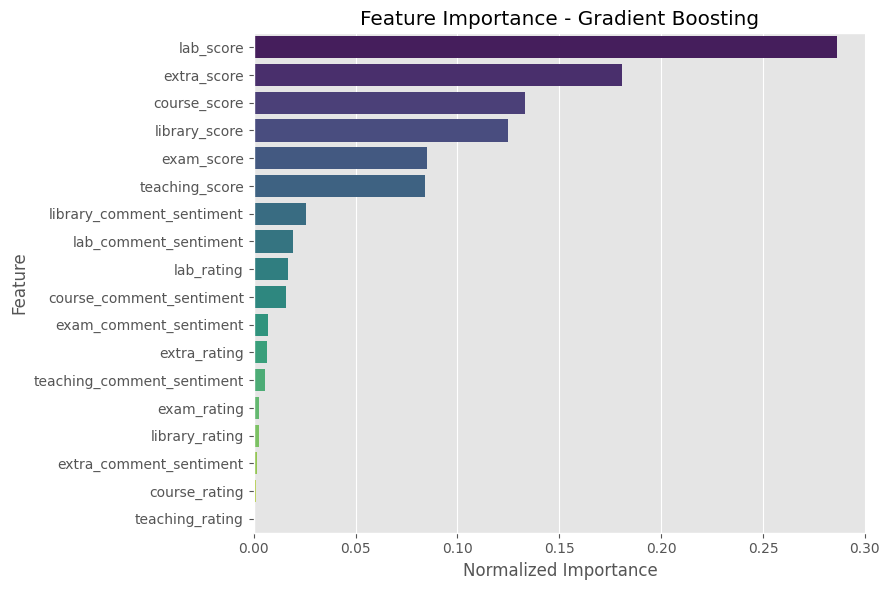

In [30]:
# End-to-end non-linear, explainable decision-support pipeline
import json
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import KFold, GridSearchCV, cross_validate, train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.impute import SimpleImputer

# -----------------------------
# Configuration
# -----------------------------
RANDOM_STATE = 42
K_FOLDS = 5
TEST_SIZE = 0.2
DATA_PATH = 'final_output_with_scores.csv'
ARTIFACT_PATH = 'student_satisfaction_best_model.joblib'
TARGET_COL = 'overall_score'

plt.style.use('ggplot')


# -----------------------------
# Utility and pipeline functions
# -----------------------------
def detect_feature_columns(df: pd.DataFrame, target_col: str) -> list:
    """Detect numeric feature columns dynamically (includes sentiment-derived numeric features)."""
    if target_col not in df.columns:
        raise ValueError(f"Missing target column: {target_col}")

    candidate_cols = [c for c in df.columns if c != target_col]
    numeric_cols = df[candidate_cols].select_dtypes(include='number').columns.tolist()

    if not numeric_cols:
        raise ValueError('No numeric feature columns found after filtering.')

    return numeric_cols


def detect_sentiment_columns(feature_cols: list) -> list:
    """Heuristically detect sentiment/text-derived numeric columns by name patterns."""
    sentiment_pattern = re.compile(
        r'(sentiment|polarity|subjectivity|emotion|opinion|vader|compound|comment)',
        flags=re.IGNORECASE
    )
    return [c for c in feature_cols if sentiment_pattern.search(c)]


def cv_summary(model, X_data, y_data, cv_obj, scoring_dict):
    scores = cross_validate(model, X_data, y_data, cv=cv_obj, scoring=scoring_dict, n_jobs=-1)
    return {
        'CV_MAE': -scores['test_MAE'].mean(),
        'CV_MSE': -scores['test_MSE'].mean(),
        'CV_R2': scores['test_R2'].mean()
    }


def model_comparison_table(models: dict, X_train, y_train, cv_obj, scoring_dict) -> pd.DataFrame:
    rows = []
    for name, model in models.items():
        row = {'Model': name}
        row.update(cv_summary(model, X_train, y_train, cv_obj, scoring_dict))
        rows.append(row)
    return pd.DataFrame(rows).sort_values('CV_R2', ascending=False).reset_index(drop=True)


def tune_random_forest(X_train, y_train, cv_obj):
    rf_param_grid = {
        'n_estimators': [200, 400, 600],
        'max_depth': [None, 6, 12, 20],
        'min_samples_split': [2, 5, 10]
    }

    rf_grid = GridSearchCV(
        estimator=RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1),
        param_grid=rf_param_grid,
        scoring='r2',
        cv=cv_obj,
        n_jobs=-1,
        verbose=0
    )
    rf_grid.fit(X_train, y_train)
    return rf_grid


def get_feature_importance(model, feature_columns: list):
    """Return normalized, sorted feature importance dict + top/least features."""
    if not hasattr(model, 'feature_importances_'):
        return {}, None, None

    raw = pd.Series(model.feature_importances_, index=feature_columns).fillna(0.0)
    total = float(raw.sum())
    normalized = (raw / total) if total > 0 else raw
    sorted_imp = normalized.sort_values(ascending=False)

    top_feature = sorted_imp.index[0] if len(sorted_imp) else None
    least_feature = sorted_imp.index[-1] if len(sorted_imp) else None

    return sorted_imp.to_dict(), top_feature, least_feature


def compare_with_simple_average(model, sample_series: pd.Series) -> dict:
    """Compare model prediction with simple arithmetic average."""
    sample_df = pd.DataFrame([sample_series])
    model_prediction = float(model.predict(sample_df)[0])
    average_score = float(sample_series.mean())

    return {
        'average_score': average_score,
        'model_prediction': model_prediction,
        'difference': model_prediction - average_score
    }


def impact_simulation(model, base_sample: pd.Series, feature_columns: list, train_reference_df: pd.DataFrame) -> dict:
    """What-if engine: increase each feature by +1 capped at training max; measure prediction delta."""
    base_pred = float(model.predict(pd.DataFrame([base_sample]))[0])
    impacts = {}

    for feature in feature_columns:
        modified = base_sample.copy()
        max_val = float(train_reference_df[feature].max())
        proposed_val = float(modified[feature]) + 1.0
        modified[feature] = min(proposed_val, max_val)

        new_pred = float(model.predict(pd.DataFrame([modified]))[0])
        impacts[feature] = new_pred - base_pred

    impacts_sorted = dict(sorted(impacts.items(), key=lambda kv: kv[1], reverse=True))
    return impacts_sorted


def non_linear_behavior_test(model, feature_name: str, base_sample: pd.Series, train_reference_df: pd.DataFrame) -> dict:
    """Move one important feature from min to max and observe prediction change."""
    if feature_name is None:
        return {'feature': None, 'change': 'Not available', 'delta': 0.0}

    min_val = float(train_reference_df[feature_name].min())
    max_val = float(train_reference_df[feature_name].max())

    x_min = base_sample.copy()
    x_max = base_sample.copy()
    x_min[feature_name] = min_val
    x_max[feature_name] = max_val

    pred_min = float(model.predict(pd.DataFrame([x_min]))[0])
    pred_max = float(model.predict(pd.DataFrame([x_max]))[0])

    return {
        'feature': feature_name,
        'change': f'{min_val:.3f} -> {max_val:.3f}',
        'delta': pred_max - pred_min
    }


def sentiment_impact_analysis(model, base_sample: pd.Series, sentiment_cols: list, train_reference_df: pd.DataFrame) -> float:
    """Compare prediction with sentiment features vs neutralized sentiment features."""
    if not sentiment_cols:
        return 0.0

    pred_with_sentiment = float(model.predict(pd.DataFrame([base_sample]))[0])

    without_sentiment_sample = base_sample.copy()
    medians = train_reference_df[sentiment_cols].median(numeric_only=True)
    for col in sentiment_cols:
        without_sentiment_sample[col] = float(medians[col])

    pred_without_sentiment = float(model.predict(pd.DataFrame([without_sentiment_sample]))[0])
    return pred_with_sentiment - pred_without_sentiment


def build_explainable_response(model, model_name: str, input_scores: dict, artifact_obj: dict) -> dict:
    """Generate production-ready explainability payload for API/Flask backend."""
    feature_columns = artifact_obj['feature_columns']
    imputer = artifact_obj['imputer']
    train_reference_df = artifact_obj['train_reference_df']
    sentiment_cols = artifact_obj['sentiment_columns']

    input_df = pd.DataFrame([input_scores]).reindex(columns=feature_columns)
    input_arr = imputer.transform(input_df)
    sample = pd.Series(input_arr[0], index=feature_columns)

    avg_vs_model = compare_with_simple_average(model, sample)

    feature_imp, top_feature, least_feature = get_feature_importance(model, feature_columns)
    impacts = impact_simulation(model, sample, feature_columns, train_reference_df)

    top_positive_factor = max(impacts, key=impacts.get) if impacts else ''
    area_to_improve = min(impacts, key=impacts.get) if impacts else ''

    nl_test_feature = top_feature if top_feature else (feature_columns[0] if feature_columns else None)
    nl_test = non_linear_behavior_test(model, nl_test_feature, sample, train_reference_df)

    sentiment_impact = sentiment_impact_analysis(model, sample, sentiment_cols, train_reference_df)

    predicted_score = float(model.predict(pd.DataFrame([sample]))[0])

    response = {
        'predicted_score': predicted_score,
        'average_score': float(avg_vs_model['average_score']),
        'difference_from_average': float(avg_vs_model['difference']),
        'model_used': model_name,
        'feature_importance': {k: float(v) for k, v in feature_imp.items()},
        'impact_analysis': {k: float(v) for k, v in impacts.items()},
        'top_positive_factor': top_positive_factor,
        'area_to_improve': area_to_improve,
        'least_important_feature': least_feature,
        'non_linear_test': {
            'feature': nl_test['feature'],
            'change': nl_test['change'],
            'delta': float(nl_test['delta'])
        },
        'sentiment_impact': float(sentiment_impact),
        'explanation': 'This model uses ensemble learning and feature importance to capture complex relationships beyond simple averaging. Model prediction deviates from average, proving learned relationships. Non-linear models capture complex feature interactions.'
    }
    return response


def train_decision_support_system(data_path: str = DATA_PATH, target_col: str = TARGET_COL):
    """Train, compare, tune, evaluate, explain, and serialize the best non-linear model."""
    df = pd.read_csv(data_path)
    feature_cols = detect_feature_columns(df, target_col)
    sentiment_cols = detect_sentiment_columns(feature_cols)

    model_df = df[feature_cols + [target_col]].copy()
    for col in feature_cols + [target_col]:
        model_df[col] = pd.to_numeric(model_df[col], errors='coerce')

    model_df = model_df.dropna(subset=[target_col]).reset_index(drop=True)
    X_raw = model_df[feature_cols]
    y = model_df[target_col]

    imputer = SimpleImputer(strategy='median')
    X = pd.DataFrame(imputer.fit_transform(X_raw), columns=feature_cols)

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE
    )

    cv = KFold(n_splits=K_FOLDS, shuffle=True, random_state=RANDOM_STATE)
    scoring = {
        'MAE': 'neg_mean_absolute_error',
        'MSE': 'neg_mean_squared_error',
        'R2': 'r2'
    }

    # Baseline comparison: RF untuned vs Gradient Boosting
    baseline_models = {
        'Random Forest (Untuned)': RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1),
        'Gradient Boosting': GradientBoostingRegressor(random_state=RANDOM_STATE)
    }
    baseline_cv_df = model_comparison_table(baseline_models, X_train, y_train, cv, scoring)

    # Tune RF and compare tuned RF vs Gradient Boosting
    rf_grid = tune_random_forest(X_train, y_train, cv)
    rf_tuned = rf_grid.best_estimator_

    comparison_models = {
        'Random Forest (Tuned)': rf_tuned,
        'Gradient Boosting': baseline_models['Gradient Boosting']
    }
    cv_compare_df = model_comparison_table(comparison_models, X_train, y_train, cv, scoring)

    # Auto-select best by R2
    best_model_name = cv_compare_df.iloc[0]['Model']
    best_model = comparison_models[best_model_name]

    # Final test evaluation
    best_model.fit(X_train, y_train)
    y_pred = best_model.predict(X_test)

    test_metrics = {
        'MAE': float(mean_absolute_error(y_test, y_pred)),
        'MSE': float(mean_squared_error(y_test, y_pred)),
        'R2': float(r2_score(y_test, y_pred))
    }

    artifact = {
        'model_name': best_model_name,
        'model': best_model,
        'imputer': imputer,
        'feature_columns': feature_cols,
        'target_column': target_col,
        'sentiment_columns': sentiment_cols,
        'cv_results': cv_compare_df,
        'baseline_cv_results': baseline_cv_df,
        'test_metrics': test_metrics,
        'train_reference_df': X_train.copy()
    }

    joblib.dump(artifact, ARTIFACT_PATH)
    return artifact


def load_model_artifact(path=ARTIFACT_PATH):
    """Load saved model artifact for backend/API use."""
    return joblib.load(path)


def predict_overall_score(new_scores: dict, artifact_obj: dict) -> float:
    """Simple score prediction (kept for compatibility)."""
    feature_columns = artifact_obj['feature_columns']
    model = artifact_obj['model']
    imp = artifact_obj['imputer']

    input_df = pd.DataFrame([new_scores]).reindex(columns=feature_columns)
    input_arr = imp.transform(input_df)
    input_processed = pd.DataFrame(input_arr, columns=feature_columns)

    pred = model.predict(input_processed)[0]
    return float(pred)


def predict_with_explainability(new_scores: dict, artifact_obj: dict) -> dict:
    """Production-ready explainable prediction payload for Flask response."""
    return build_explainable_response(
        model=artifact_obj['model'],
        model_name=artifact_obj['model_name'],
        input_scores=new_scores,
        artifact_obj=artifact_obj
    )


# -----------------------------
# Train + quick demonstration
# -----------------------------
artifact = train_decision_support_system(DATA_PATH, TARGET_COL)
print('Training complete.')
print('Selected model:', artifact['model_name'])
print('Best RF params (if RF selected/tuned): available via GridSearch during training')
print('Test metrics:', artifact['test_metrics'])
print('\n5-Fold CV model comparison:')
display(artifact['cv_results'].round(4))

sample_input = {
    'teaching_score': 4.3,
    'course_score': 4.0,
    'exam_score': 3.7,
    'lab_score': 4.1,
    'library_score': 3.9,
    'extra_score': 4.2
}

# Add missing features (including possible sentiment columns) with NaN; imputer handles alignment
for col in artifact['feature_columns']:
    if col not in sample_input:
        sample_input[col] = np.nan

api_response = predict_with_explainability(sample_input, artifact)
print('\nExplainable API payload:')
print(json.dumps(api_response, indent=2))

# Optional: visualize feature importance if available
fi = api_response.get('feature_importance', {})
if fi:
    fi_series = pd.Series(fi).sort_values(ascending=False)
    plt.figure(figsize=(9, 6))
    sns.barplot(x=fi_series.values, y=fi_series.index, palette='viridis')
    plt.title(f"Feature Importance - {artifact['model_name']}")
    plt.xlabel('Normalized Importance')
    plt.ylabel('Feature')
    plt.tight_layout()
    plt.show()